In [95]:
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def four_point_transform(image, pts, size=300):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = int(max(widthA, widthB, size))
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = int(max(heightA, heightB, size))
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    warped = cv2.resize(warped, (size, size))
    return warped

def find_cube_face_contour(img_gray, min_area=1000):
    blurred = cv2.GaussianBlur(img_gray, (5,5), 0)
    edged = cv2.Canny(blurred, 50, 150)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:
            return approx.reshape(4,2)

    if contours:
        cnt = contours[0]
        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect)
        return box
    return None

COLOR_CENTROIDS = {
    'White': np.array([0, 20, 240]),
    'White':np.array([100, 20, 250]),
    'Yellow': np.array([28, 200, 230]),
    'Red': np.array([0, 200, 180]),
    'Orange': np.array([12, 220, 200]),
    'Blue': np.array([110, 200, 140]),
    'Green': np.array([60, 200, 140])
}

def adjust_for_red(hsv):
    h = hsv[0]
    if h > 160:
        return np.array([h - 180, hsv[1], hsv[2]])
    return hsv

def color_distance(hsv, centroid):
    hsv_adj = np.array(hsv, dtype=float)
    cent = np.array(centroid, dtype=float)
    if cent[0] < 10:
        if hsv_adj[0] > 160:
            hsv_adj[0] -= 180

    dh = min(abs(hsv_adj[0] - cent[0]), 180 - abs(hsv_adj[0] - cent[0])) / 180.0
    ds = abs(hsv_adj[1] - cent[1]) / 255.0
    dv = abs(hsv_adj[2] - cent[2]) / 255.0

    return dh * 2.0 + ds * 1.0 + dv * 0.8

def match_color(hsv):
    best = None
    best_dist = 1e9

    h, s, v = hsv
    if s < 40 and v > 160:
        return "White"
    
    for name, cent in COLOR_CENTROIDS.items():
        d = color_distance(hsv, cent)
        if d < best_dist:
            best_dist = d
            best = name
    return best

def detect_rubik_face_colors(img_bgr):
    orig = img_bgr.copy()
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    contour = find_cube_face_contour(gray, min_area=500)
    if contour is None:
        raise RuntimeError("Surface not detected. Try other photo or upscale source quality")
    warped = four_point_transform(orig, contour, size=300)

    lab = cv2.cvtColor(warped, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l2 = clahe.apply(l)
    lab = cv2.merge((l2, a, b))
    warped = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    hsv = cv2.cvtColor(warped, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    size = hsv.shape[0]
    cell = size // 3
    colors = []

    vis = warped.copy()
    for row in range(3):
        row_colors = []
        for col in range(3):
            y1 = row * cell + int(cell*0.15)
            y2 = (row+1) * cell - int(cell*0.15)
            x1 = col * cell + int(cell*0.15)
            x2 = (col+1) * cell - int(cell*0.15)
            patch = hsv[y1:y2, x1:x2]

            mask = patch[:,:,2] > 40  # V > 40
            if np.count_nonzero(mask) == 0:
                avg = np.array([0,0,0])
            else:
                avg_h = np.mean(patch[:,:,0][mask])
                avg_s = np.mean(patch[:,:,1][mask])
                avg_v = np.mean(patch[:,:,2][mask])
                avg = np.array([avg_h, avg_s, avg_v])
            name = match_color(avg)
            row_colors.append(name)

            cv2.rectangle(vis, (x1, y1), (x2, y2), (0,0,0), 2)
            cv2.putText(vis, name[0], (x1+5, y1+20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        colors.append(row_colors)
    return colors, warped, vis

def scan_surface(img_path):
    if not os.path.exists(img_path):
        print("File not found", img_path)
        return
    img = cv2.imread(img_path)
    if img is None:
        print("Not supported source format (JPEG/PNG only)")
        return
    try:
        colors, warped, vis = detect_rubik_face_colors(img)
    except Exception as e:
        print("While detect throwed exeption:", e)
        return

    print("Detected colors:")
    for r in colors:
        print(r)

    out_name = "out_" + os.path.basename(img_path)
    cv2.imwrite(out_name, vis)
    print("Saved as", out_name)

    try:
        vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
        warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
        fig, axs = plt.subplots(1,2, figsize=(10,5))
        axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[0].set_title('Original')
        axs[0].axis('off')
        axs[1].imshow(vis_rgb)
        axs[1].set_title('Warp + grid')
        axs[1].axis('off')
        plt.show()
    except Exception:
        pass
    finally:
        return colors


Detected colors:
['Green', 'Green', 'White']
['Green', 'Green', 'Red']
['Green', 'Green', 'Red']
Saved as out_up.jpg


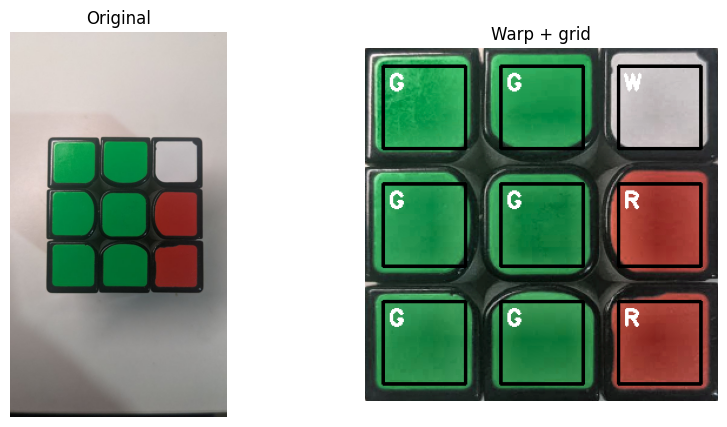

Detected colors:
['White', 'White', 'Blue']
['Red', 'Red', 'Blue']
['Red', 'Red', 'Blue']
Saved as out_front.jpg


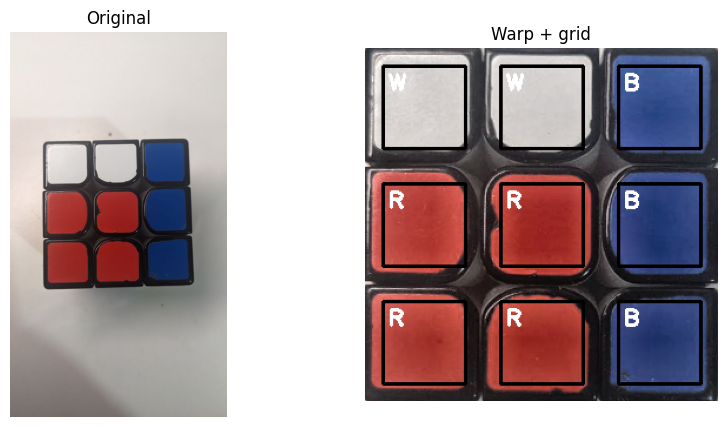

Detected colors:
['Red', 'Red', 'Red']
['Yellow', 'Yellow', 'Yellow']
['Yellow', 'Yellow', 'Yellow']
Saved as out_left.jpg


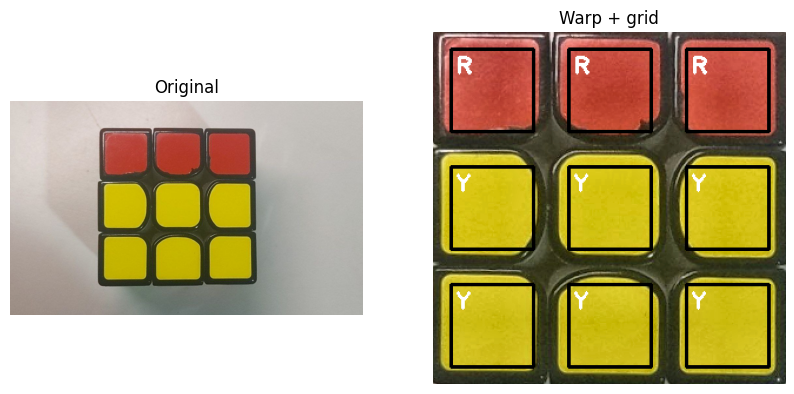

Detected colors:
['White', 'White', 'Orange']
['White', 'White', 'Orange']
['White', 'White', 'Orange']
Saved as out_right.jpg


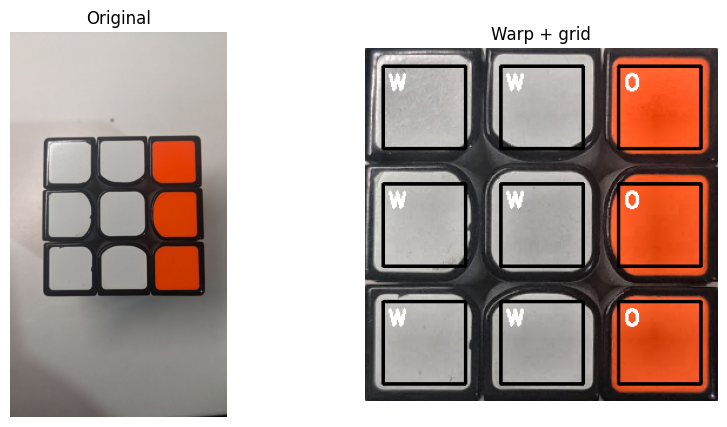

Detected colors:
['Green', 'Yellow', 'Yellow']
['Green', 'Orange', 'Orange']
['Green', 'Orange', 'Orange']
Saved as out_back.jpg


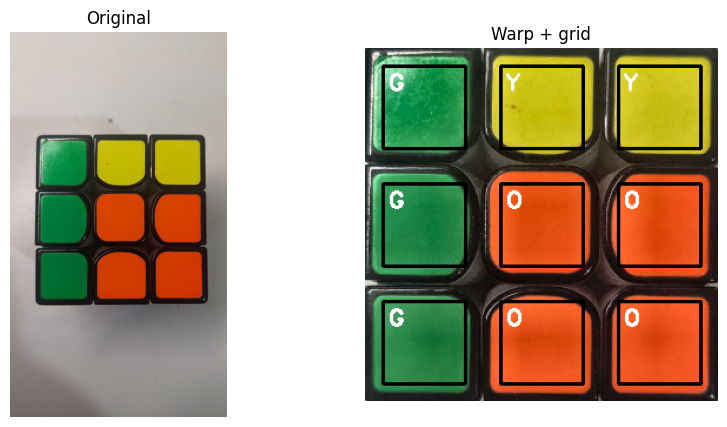

Detected colors:
['Blue', 'Blue', 'Orange']
['Blue', 'Blue', 'Orange']
['Blue', 'Blue', 'Yellow']
Saved as out_down.jpg


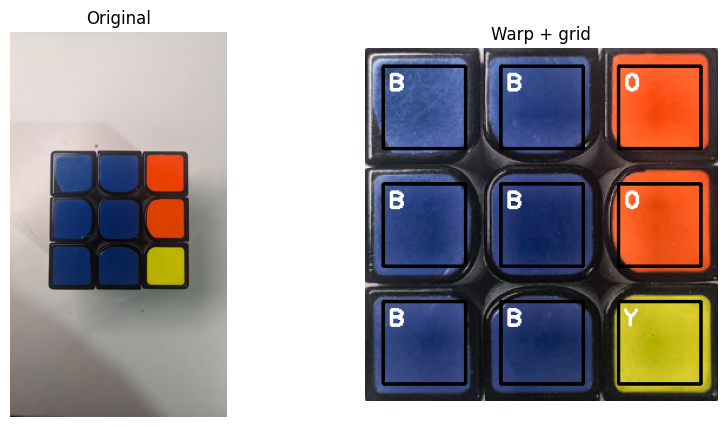

In [98]:
surfaces = ["up", "front", "left", "right", "back", "down"]

colors = []

for s in surfaces:
    colors.append(scan_surface(f"{s}.jpg"))

### Draw a net of the cube

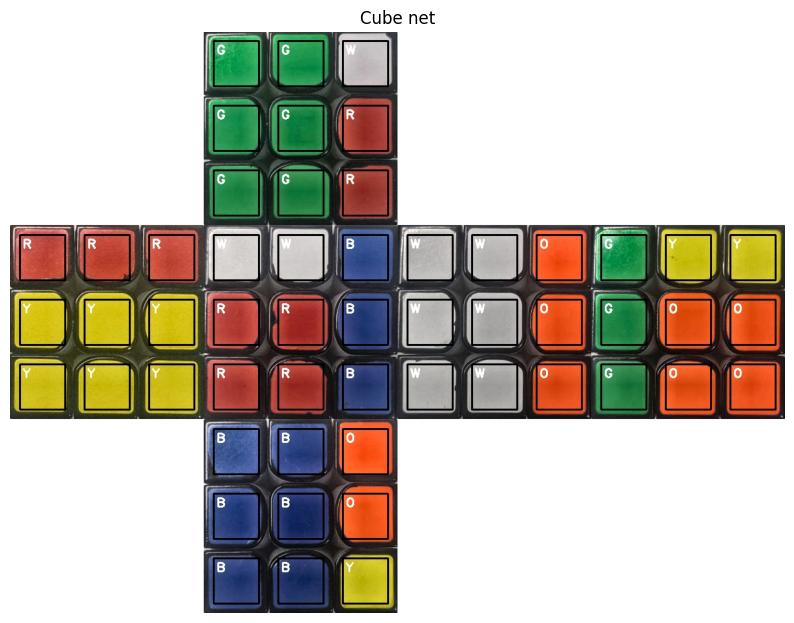

[[['Green', 'Green', 'White'], ['Green', 'Green', 'Red'], ['Green', 'Green', 'Red']], [['White', 'White', 'Blue'], ['Red', 'Red', 'Blue'], ['Red', 'Red', 'Blue']], [['Red', 'Red', 'Red'], ['Yellow', 'Yellow', 'Yellow'], ['Yellow', 'Yellow', 'Yellow']], [['White', 'White', 'Orange'], ['White', 'White', 'Orange'], ['White', 'White', 'Orange']], [['Green', 'Yellow', 'Yellow'], ['Green', 'Orange', 'Orange'], ['Green', 'Orange', 'Orange']], [['Blue', 'Blue', 'Orange'], ['Blue', 'Blue', 'Orange'], ['Blue', 'Blue', 'Yellow']]]


In [99]:
import glob

out_folder='.'

images = {}
for path in glob.glob(os.path.join(out_folder, 'out_*.jpg')):
    name = os.path.basename(path).replace('out_', '').replace('.jpg', '')
    img = cv2.imread(path)
    if img is not None:
        images[name.lower()] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = list(images.values())[0].shape if images else (300, 300, 3)
size = h

net = np.ones((size * 3, size * 4, 3), dtype=np.uint8) * 255

def place(name, row, col):
    if name in images:
        net[row*size:(row+1)*size, col*size:(col+1)*size] = images[name]
    else:
        cv2.putText(net, name.upper(), (col*size + 50, row*size + 150),
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 3)

#        [UP]
# [LEFT] [FRONT] [RIGHT] [BACK]
#        [DOWN]
place('up',    0, 1)
place('left',  1, 0)
place('front', 1, 1)
place('right', 1, 2)
place('back',  1, 3)
place('down',  2, 1)

plt.figure(figsize=(10, 8))
plt.imshow(net)
plt.axis('off')
plt.title('Cube net')
plt.show()

print(colors)

In [102]:
import kociemba

color_to_face = {
    colors[0][1][1]: 'U', 
    colors[1][1][1]: 'F',
    colors[2][1][1]: 'L',
    colors[3][1][1]: 'R',
    colors[4][1][1]: 'B',
    colors[5][1][1]: 'D',
}

def face_to_string(face):
    return ''.join(''.join(row) for row in face)

def color_to_code(color):
    for c, code in color_to_face.items():
        if color == c:
            return code
    raise ValueError(f"Unknown color: {color}")

encoded_faces = [
    [[color_to_code(color) for color in row] for row in face]
    for face in colors
]

# ["up", "front", "left", "right", "back", "down"] current

order = [0, 3, 1, 5, 2, 4]

cube_string = ''.join(
    ''.join(''.join(row) for row in encoded_faces[i])
    for i in order
)

print("Cube string:", cube_string)

solution = kociemba.solve(cube_string)
print("Solution:", solution)

Cube string: UURUUFUUFRRBRRBRRBRRDFFDFFDDDBDDBDDLFFFLLLLLLULLUBBUBB
Solution: R' U'


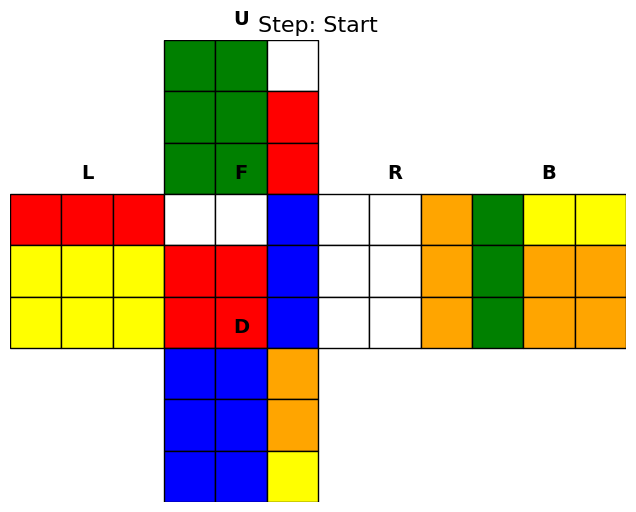

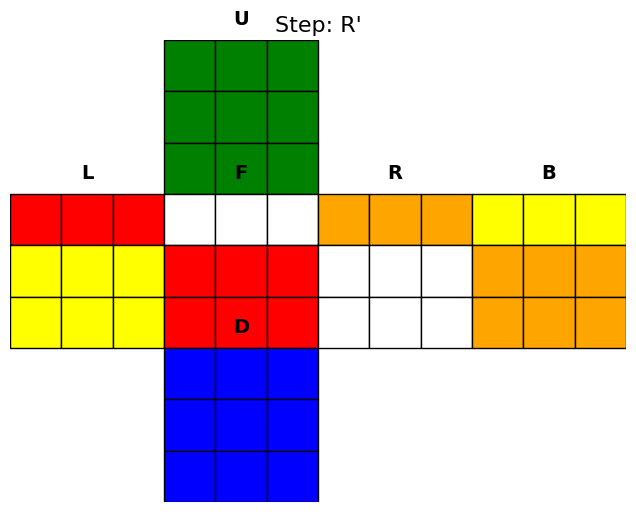

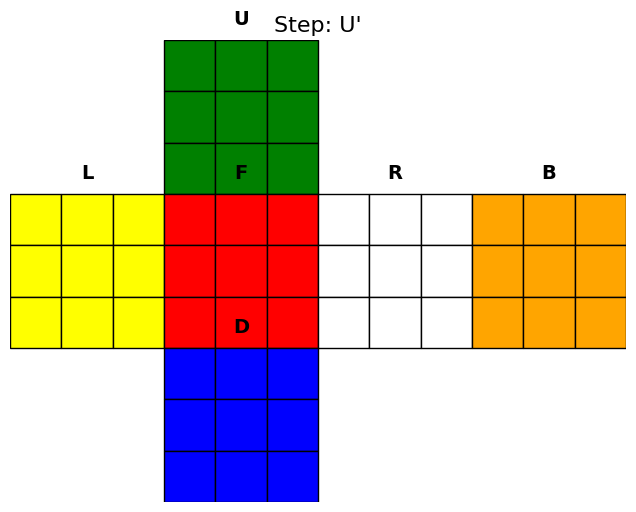

In [108]:
color_map = {
    'U': 'green',
    'D': 'blue',
    'F': 'red',
    'B': 'orange',
    'L': 'yellow',
    'R': 'white'
}

layout = {
    'U': (3, 0),
    'L': (0, 3),
    'F': (3, 3),
    'R': (6, 3),
    'B': (9, 3),
    'D': (3, 6)
}

def parse_cube(cube_str):
    faces = {}
    order = ['U', 'R', 'F', 'D', 'L', 'B']
    i = 0
    for face in order:
        face_colors = [[cube_str[i + r * 3 + c] for c in range(3)] for r in range(3)]
        faces[face] = face_colors
        i += 9
    return faces

# Функция рисования
def draw_cube(faces, step=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')

    for name, (x0, y0) in layout.items():
        face = faces[name]
        for i in range(3):
            for j in range(3):
                rect = plt.Rectangle(
                    (x0 + j, y0 + i),
                    1, 1,
                    facecolor=color_map[face[i][j]],
                    edgecolor='black'
                )
                ax.add_patch(rect)
        ax.text(x0 + 1.5, y0 - 0.3, name, ha='center', fontsize=14, weight='bold')

    if step:
        ax.set_title(f"Step: {step}", fontsize=16)
    plt.gca().invert_yaxis()
    plt.show()

def rotate_face(face, times=1):
    return np.rot90(face, -times).tolist()

def apply_move(faces, move):
    move = move.strip()
    clockwise = not move.endswith("'")
    move_name = move[0]

    if move_name == 'R':
        faces['R'] = rotate_face(faces['R'], 1 if clockwise else 3)
        temp = [row[2] for row in faces['U']]
        if clockwise:
            for i in range(3):
                faces['U'][i][2] = faces['F'][i][2]
                faces['F'][i][2] = faces['D'][i][2]
                faces['D'][i][2] = faces['B'][2 - i][0]
                faces['B'][2 - i][0] = temp[i]
        else:
            for i in range(3):
                faces['U'][i][2] = faces['B'][2 - i][0]
                faces['B'][2 - i][0] = faces['D'][i][2]
                faces['D'][i][2] = faces['F'][i][2]
                faces['F'][i][2] = temp[i]

    elif move_name == 'U':
        faces['U'] = rotate_face(faces['U'], 1 if clockwise else 3)
        temp = faces['F'][0][:]
        if clockwise:
            faces['F'][0] = faces['R'][0][:]
            faces['R'][0] = faces['B'][0][:]
            faces['B'][0] = faces['L'][0][:]
            faces['L'][0] = temp
        else:
            faces['F'][0] = faces['L'][0][:]
            faces['L'][0] = faces['B'][0][:]
            faces['B'][0] = faces['R'][0][:]
            faces['R'][0] = temp

faces = parse_cube(cube_string)
draw_cube(faces, "Start")

if isinstance(solution, str):
    moves = [m.strip() for m in solution.split() if m.strip()]
else:
    moves = [m.strip() for m in solution if m.strip()]

for move in moves:
    apply_move(faces, move)
    draw_cube(faces, move)